# Project 3 · 01：从 Relax IR 到 Custom NPU partition——第一次拥有 Backend Contract

> **一句话心智模型：** `Relax` 是 TVM 中描述 model-level tensor program 的高层 IR；这本实验让我们第一次自己规定“什么 graph pattern 可以交给 backend、还必须满足哪些 dtype/shape/alignment 条件”，而不是只能观察厂商 compiler 的最终结果。

这是 `Learning-Guide.md` 中 **Project 3 — TVM Relax NPU Backend & Operator AutoTuning** 的第一份实验，只建立 **P3.1 Relax Backend Baseline**。

完成本实验后，你应该能从第一性原理回答：

1. `IRModule → Function → DataflowBlock → Binding → Call` 在内存里分别维护什么 compiler 对象？
2. 为什么 `pattern matching`（在 graph 中识别指定 op/依赖结构）之后仍必须有 `support check`？
3. `Composite`、`Codegen`、`partition coverage`、`fallback` 分别证明了什么，又不能证明什么？
4. 为什么 `partition 成功 ≠ codegen 成功 ≠ runtime 真执行 ≠ correctness ≠ performance`？
5. 把同一套 backend contract 迁移到公司 Custom NPU 时，应该怎样测试 capability、partition、artifact、runtime placement 和性能？

Project 3 后续会进入 `compiler lowering`（把高层 op 逐步改写成更接近 target 的低层表示）、TIR、implementation selection 和 `kernel scheduling`（编译期决定 loop 怎样 tile/reorder/vectorize/parallel）。本 notebook 先把 graph ownership 的证据链做扎实。

## Goal：从 Project 1/2 的已有状态，推导为什么现在需要 Backend API

Project 1 和 Project 2 已经建立：

```text
fixed model / input / preprocessing
            ↓
FP32 / FP16 / INT8 precision contract
            ↓
graph inspection + correctness gate
            ↓
benchmark + profiler evidence
```

但我们仍然只能**接受现有 compiler 已经做出的选择**。即使 Project 2 已决定某层用 FP16 还是 INT8，也还没有回答：这个 subgraph 能不能交给自研 backend？应该选哪个 kernel？为什么发生 fallback？

| 已达到的状态 | 还缺什么能力 | 因此引入的新功能 / 接口 |
|---|---|---|
| 能看到 ONNX / MIL graph | 不能用 compiler 对象表达 model-level program | Relax `IRModule` / `Function` / `Call` |
| 知道某个 op 名叫 MatMul | 不知道一串 op 是否构成 backend 可融合的 subgraph | DPL pattern、`FusionPattern` |
| graph 结构匹配 | 不知道 dtype、shape、rank、layout、alignment 是否合法 | `PatternCheckContext`、support checker |
| 已识别合法 subgraph | host 与 accelerator 的 graph ownership 尚未切开 | `FuseOpsByPattern`、`Composite`、`Codegen` attributes |
| 已形成 planned partition | 没有 target module，也没有设备调用 | `RunCodegen`、FFI codegen key、runtime module |
| 编译/运行返回成功 | 不知道语义是否保持、设备是否真执行 | reference parity、错误 golden 负控、runtime event / placement |

把这条链记住；它是本 notebook 会重复强化的核心：

```text
pattern match → support check → partition → codegen → runtime → correctness → performance
```

## 本实验边界：先拥有 Backend Contract，不假装一次做完整个 Project 3

本实验使用真实 `apache-tvm==0.26.0` Relax API 和 LLVM CPU runtime；toy backend 的 alignment/local-memory 数字是**明确标注的教学合同**，不是 Apple ANE 或公司 NPU 的硬件规格。

| 本次完成 | 后续再做 | 为什么现在不做 |
|---|---|---|
| Relax IR 构造与对象检视 | PyTorch / ONNX 大模型导入 | 先把一个四五节点 graph 的每一步看清，再增加 frontend 噪声 |
| `matmul + bias + relu` pattern | 大规模 pattern library | 首先区分结构匹配与 capability 合法性 |
| 三组正例/负控、coverage/fallback instrumentation | Relax → TIR target lowering | lowering 是下一本 notebook 的独立 ownership 层 |
| LLVM 上 original vs semantic-grouped parity | Custom NPU external runtime | 当前 PyPI wheel 没有为本教学 backend 注册 codegen/runtime |
| 明确触发并拦截 `RunCodegen` 缺失 | latency / AutoTuning / cost model | mock backend 没有真实执行，画“加速比”会制造伪证据 |

M1 在这里负责“机制可复现”：Relax、DPL、partition、LLVM correctness。它**不能**证明 Metal、ANE 或公司 NPU 性能。公司台架扩展只在最后给出证据路径，不阻塞本地实验。

## Setup：启动方式与实验合同

从仓库根目录执行：

```bash
uv sync
uv run jupyter lab notebooks/project3_backend_autotuning/01_relax_pattern_partition_backend_contract.ipynb
```

最小 CLI 自检：

```bash
uv run python -c "import tvm; print(tvm.__version__, tvm.support.libinfo()['USE_LLVM'])"
```

- `uv run`：使用本仓库 lockfile 对应的 Python 环境，而不是系统 Python。
- `tvm.__version__`：确认 notebook 与 API 文档对应的版本。
- `USE_LLVM`：确认当前 TVM wheel 是否能把 host-side TIR/code 编译成 CPU native code。

本实验固定：

- NumPy seed = `7`；LLVM CPU target；4 个 runtime thread；
- supported case 为 `[M,K]=[8,16] @ [K,N]=[16,16]`，dtype=`float32`；
- toy capability 要求 `K`、`N` 都按 16 对齐，估算 working set 不超过 64 KiB；
- `sin` 故意不进入 pattern，制造一个可观察的 host fallback；
- coverage 的分母明确为 **original Relax primitive op node count**，不是 FLOPs、字节数或 latency；
- correctness 通过前不报告任何性能数字；profiler 与产品 benchmark 不混跑。

In [1]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import os
import platform
import subprocess
import warnings

os.environ["TVM_NUM_THREADS"] = "4"
warnings.filterwarnings(
    "ignore",
    message="Failed to JIT torch c dlpack extension.*",
)

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import tvm
from IPython.display import Markdown, display
from tvm import relax
from tvm.relax.backend.pattern_registry import (
    get_pattern,
    get_patterns_with_prefix,
    register_patterns,
)
from tvm.relax.backend.patterns import make_matmul_pattern
from tvm.relax.transform import (
    FuseOpsByPattern,
    MergeCompositeFunctions,
    RunCodegen,
)

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_DIR = ROOT / "artifacts" / "project3_relax_backend"
RUN_DIR = ROOT / "results" / "project3_relax_backend" / RUN_ID
for path in [ARTIFACT_DIR, RUN_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CPU_THREADS = 4
RANDOM_SEED = 7
LOCAL_MEMORY_BUDGET_BYTES = 64 * 1024
ALIGNMENT_ELEMENTS = 16
LLVM_TARGET = "llvm"
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 120)

BLUE = "#4C78A8"
ORANGE = "#F58518"
GRAY = "#9CA3AF"

def command_output(command: list[str]) -> str:
    return subprocess.check_output(command, text=True).strip()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

libinfo = tvm.support.libinfo()
environment = {
    "run_id": RUN_ID,
    "python": platform.python_version(),
    "macOS": platform.mac_ver()[0],
    "machine": platform.machine(),
    "chip": command_output(["sysctl", "-n", "machdep.cpu.brand_string"]),
    "tvm": tvm.__version__,
    "TVM git commit": libinfo.get("GIT_COMMIT_HASH", "unknown"),
    "USE_LLVM": libinfo.get("USE_LLVM", "unknown"),
    "USE_METAL (compiler build flag)": libinfo.get("USE_METAL", "unknown"),
    "experiment target": LLVM_TARGET,
    "runtime threads": CPU_THREADS,
}
display(pd.Series(environment, name="value").to_frame())
assert libinfo.get("USE_LLVM") == "ON", "This notebook needs a TVM wheel built with LLVM."

,value
run_id,20260903-000943
python,3.12.11
macOS,26.6.2
machine,arm64
chip,Apple M1
tvm,0.26.0
TVM git commit,unknown
USE_LLVM,ON
USE_METAL (compiler build flag),OFF
experiment target,llvm


### 先锁定 target，防止把“在 M1 上运行”误写成“使用了 M1 GPU/ANE”

`USE_METAL=OFF` 与 `target="llvm"` 共同说明：本 notebook 的可执行结果来自 M1 CPU native code。Apple Silicon 是机器平台，不自动等于 Metal GPU，更不等于 ANE。

后续如果增加 Metal lane，必须同时保存 TVM build flag、target string、device availability、生成代码和同步方式；如果增加 ANE lane，则要通过 Core ML runtime/profiler 另建证据链，不能从本实验外推。

## Steps 1：先让一个实际 tensor 演完 `MatMul → Bias → ReLU → Sin`

轴身份先固定：

- `X[M,K]`：`M` 是 output/production axis，代表输出的行；`K` 是 reduction axis，会在点积中被求和。
- `W[K,N]`：`N` 是另一个 output/production axis，代表输出的列。
- `bias[N]`：沿 `M` 轴广播；同一列共享一个 bias。
- 输出 `Y[M,N]`：每个元素由一整条 `K` reduction 产生。

先用 `M=2, K=3, N=2`。假设三个 row-major FP32 buffer 的起始地址分别是 `0x1000 / 0x2000 / 0x3000`。这些地址是教学用的显式 base，不是 Python 对象的真实虚拟地址；每个 FP32 占 4 bytes。

In [2]:
X_TOY = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
W_TOY = np.array([[1, 0], [0, 1], [1, 1]], dtype=np.float32)
BIAS_TOY = np.array([1, -1], dtype=np.float32)
BASE_ADDRESSES = {"X": 0x1000, "W": 0x2000, "bias": 0x3000}

def physical_memory_table(name: str, tensor: np.ndarray) -> pd.DataFrame:
    rows = []
    for coordinate in np.ndindex(tensor.shape):
        element_offset = int(np.ravel_multi_index(coordinate, tensor.shape))
        byte_offset = element_offset * tensor.itemsize
        rows.append(
            {
                "buffer": name,
                "coordinate": str(coordinate),
                "element offset": element_offset,
                "byte address": hex(BASE_ADDRESSES[name] + byte_offset),
                "value": float(tensor[coordinate]),
            }
        )
    return pd.DataFrame(rows)

memory_table = pd.concat(
    [
        physical_memory_table("X", X_TOY),
        physical_memory_table("W", W_TOY),
        physical_memory_table("bias", BIAS_TOY),
    ],
    ignore_index=True,
)
display(memory_table)

contribution_rows = []
for m in range(X_TOY.shape[0]):
    for n in range(W_TOY.shape[1]):
        for k in range(X_TOY.shape[1]):
            x_offset = m * X_TOY.shape[1] + k
            w_offset = k * W_TOY.shape[1] + n
            contribution_rows.append(
                {
                    "output coordinate": f"({m}, {n})",
                    "k": k,
                    "X read": f"X[{m},{k}] @ {hex(0x1000 + 4 * x_offset)}",
                    "W read": f"W[{k},{n}] @ {hex(0x2000 + 4 * w_offset)}",
                    "multiply": f"{X_TOY[m, k]:.0f} × {W_TOY[k, n]:.0f}",
                    "contribution": float(X_TOY[m, k] * W_TOY[k, n]),
                }
            )
display(pd.DataFrame(contribution_rows))

matmul_toy = X_TOY @ W_TOY
biased_toy = matmul_toy + BIAS_TOY
relu_toy = np.maximum(biased_toy, 0)
final_toy = np.sin(relu_toy)
display(
    pd.DataFrame(
        {
            "MatMul": matmul_toy.ravel(),
            "+ bias": biased_toy.ravel(),
            "ReLU": relu_toy.ravel(),
            "Sin": final_toy.ravel(),
        },
        index=["Y[0,0]", "Y[0,1]", "Y[1,0]", "Y[1,1]"],
    )
)
np.testing.assert_array_equal(matmul_toy, np.array([[4, 5], [10, 11]], dtype=np.float32))
np.testing.assert_array_equal(relu_toy, np.array([[5, 4], [11, 10]], dtype=np.float32))

,buffer,coordinate,element offset,byte address,value
0,X,"(0, 0)",0,0x1000,1.0
1,X,"(0, 1)",1,0x1004,2.0
2,X,"(0, 2)",2,0x1008,3.0
3,X,"(1, 0)",3,0x100c,4.0
4,X,"(1, 1)",4,0x1010,5.0
5,X,"(1, 2)",5,0x1014,6.0
6,W,"(0, 0)",0,0x2000,1.0
7,W,"(0, 1)",1,0x2004,0.0
8,W,"(1, 0)",2,0x2008,0.0
9,W,"(1, 1)",3,0x200c,1.0


,output coordinate,k,X read,W read,multiply,contribution
0,"(0, 0)",0,"X[0,0] @ 0x1000","W[0,0] @ 0x2000",1 × 1,1.0
1,"(0, 0)",1,"X[0,1] @ 0x1004","W[1,0] @ 0x2008",2 × 0,0.0
2,"(0, 0)",2,"X[0,2] @ 0x1008","W[2,0] @ 0x2010",3 × 1,3.0
3,"(0, 1)",0,"X[0,0] @ 0x1000","W[0,1] @ 0x2004",1 × 0,0.0
4,"(0, 1)",1,"X[0,1] @ 0x1004","W[1,1] @ 0x200c",2 × 1,2.0
5,"(0, 1)",2,"X[0,2] @ 0x1008","W[2,1] @ 0x2014",3 × 1,3.0
6,"(1, 0)",0,"X[1,0] @ 0x100c","W[0,0] @ 0x2000",4 × 1,4.0
7,"(1, 0)",1,"X[1,1] @ 0x1010","W[1,0] @ 0x2008",5 × 0,0.0
8,"(1, 0)",2,"X[1,2] @ 0x1014","W[2,0] @ 0x2010",6 × 1,6.0
9,"(1, 1)",0,"X[1,0] @ 0x100c","W[0,1] @ 0x2004",4 × 0,0.0


,MatMul,+ bias,ReLU,Sin
"Y[0,0]",4.0,5.0,5.0,-0.958924
"Y[0,1]",5.0,4.0,4.0,-0.756802
"Y[1,0]",10.0,11.0,11.0,-0.999990
"Y[1,1]",11.0,10.0,10.0,-0.544021


### 从数字回到机制，再压缩成符号

以 `Y[0,0]` 为例，CPU/kernel 实际读取：

```text
X[0,0] @ 0x1000 × W[0,0] @ 0x2000 = 1
X[0,1] @ 0x1004 × W[1,0] @ 0x2008 = 0
X[0,2] @ 0x1008 × W[2,0] @ 0x2010 = 3
reduction sum = 4 → + bias[0]=1 → ReLU = 5 → sin(5)
```

compiler 不能改变这段数学语义，只能改变“谁执行、loop 怎么组织、何时搬数据”。最后才写紧凑公式：

```text
Z[m,n] = Σ_k X[m,k] × W[k,n]
A[m,n] = max(Z[m,n] + bias[n], 0)
Y[m,n] = sin(A[m,n])
```

这里的 `Σ_k` 就是把刚才表中同一 `(m,n)` 的三行 contribution 累加；它不是一种新操作。

## Steps 2：用真实 Relax 对象表达同一条数据流

`BlockBuilder` 实际上是一个受作用域约束的 IR 构造器：进入 `function/dataflow` scope 后，每次 `emit` 都创建一个 SSA binding——一个新变量只定义一次，并绑定到一个 `Call` 或其他 expression。

```text
IRModule
  └── Function main(x, w, bias)
        └── DataflowBlock
              ├── matmul = Call(relax.matmul, ...)
              ├── bias_add = Call(relax.add, ...)
              ├── relu = Call(relax.nn.relu, ...)
              └── host_sin = Call(relax.sin, ...)
```

这和你熟悉的 compiler AST/CFG 数据结构很接近：`IRModule` 管全局符号，`Function` 管参数和 body，block 保存有序 bindings，`Var` 建立 def-use 边，`Call.op` 指向具体 operator。

In [3]:
CASE_SPECS = {
    "supported_with_fallback": {
        "M": 8,
        "K": 16,
        "N": 16,
        "dtype": "float32",
        "break_pattern": False,
    },
    "pattern_mismatch": {
        "M": 8,
        "K": 16,
        "N": 16,
        "dtype": "float32",
        "break_pattern": True,
    },
    "support_rejected": {
        "M": 8,
        "K": 12,
        "N": 15,
        "dtype": "float32",
        "break_pattern": False,
    },
}

def make_relax_module(spec: dict) -> tvm.IRModule:
    m, k, n = spec["M"], spec["K"], spec["N"]
    dtype = spec["dtype"]
    builder = relax.BlockBuilder()
    x = relax.Var("x", relax.TensorType([m, k], dtype))
    weight = relax.Var("weight", relax.TensorType([k, n], dtype))
    bias = relax.Var("bias", relax.TensorType([n], dtype))

    with builder.function("main", [x, weight, bias]):
        with builder.dataflow():
            matmul = builder.emit(relax.op.matmul(x, weight), name_hint="matmul")
            if spec["break_pattern"]:
                matmul = builder.emit(
                    relax.op.reshape(matmul, (m, n)),
                    name_hint="reshape_break",
                )
            bias_add = builder.emit(relax.op.add(matmul, bias), name_hint="bias_add")
            activation = builder.emit(relax.op.nn.relu(bias_add), name_hint="relu")
            host_sin = builder.emit(relax.op.sin(activation), name_hint="host_sin")
            output = builder.emit_output(host_sin)
        builder.emit_func_output(output)
    return builder.get()

original_modules = {
    case_name: make_relax_module(spec)
    for case_name, spec in CASE_SPECS.items()
}
print(original_modules["supported_with_fallback"].script())

# from tvm.script import ir as I
# from tvm.script import relax as R

@I.ir_module
class Module:
    @R.function
    def main(x: R.Tensor((8, 16), dtype="float32"), weight: R.Tensor((16, 16), dtype="float32"), bias: R.Tensor((16,), dtype="float32")) -> R.Tensor((8, 16), dtype="float32"):
        with R.dataflow():
            matmul: R.Tensor((8, 16), dtype="float32") = R.matmul(x, weight, out_dtype=None)
            bias_add: R.Tensor((8, 16), dtype="float32") = R.add(matmul, bias)
            relu: R.Tensor((8, 16), dtype="float32") = R.nn.relu(bias_add)
            host_sin: R.Tensor((8, 16), dtype="float32") = R.sin(relu)
            gv: R.Tensor((8, 16), dtype="float32") = host_sin
            R.output(gv)
        return gv


In [4]:
def operator_name(value) -> str:
    if isinstance(value, relax.Call) and isinstance(value.op, tvm.ir.Op):
        return value.op.name
    return type(value).__name__

binding_rows = []
main_function = original_modules["supported_with_fallback"]["main"]
for block_index, block in enumerate(main_function.body.blocks):
    for binding_index, binding in enumerate(block.bindings):
        binding_rows.append(
            {
                "block": block_index,
                "binding": binding_index,
                "SSA variable": binding.var.name,
                "value object": type(binding.value).__name__,
                "operator": operator_name(binding.value),
                "inferred type": str(binding.var.ty),
            }
        )
display(pd.DataFrame(binding_rows))

,block,binding,SSA variable,value object,operator,inferred type
0,0,0,matmul,Call,relax.matmul,"R.Tensor((8, 16), dtype=""float32"")"
1,0,1,bias_add,Call,relax.add,"R.Tensor((8, 16), dtype=""float32"")"
2,0,2,relu,Call,relax.nn.relu,"R.Tensor((8, 16), dtype=""float32"")"
3,0,3,host_sin,Call,relax.sin,"R.Tensor((8, 16), dtype=""float32"")"
4,0,4,gv,DataflowVar,DataflowVar,"R.Tensor((8, 16), dtype=""float32"")"


## Steps 3：先写 capability contract，再写 pattern

`pattern matching` 只回答“graph 形状像不像”：这里寻找 `matmul → add(bias) → relu`。但名字匹配不能证明 target 能执行它。

一个真实 backend 还必须检查：

```text
op semantics
  + dtype / rank / static-or-dynamic shape
  + logical & physical layout
  + alignment / local memory / resource limits
  = implementation legality
```

因此我们把 capability 写成一个可单测、可输出 rejection reason 的纯函数，再让 TVM `PatternCheckContext` 调用同一份逻辑。这里的 `K,N % 16 == 0` 和 64 KiB 是 toy policy；它们的价值是演示**合同存在于哪一层**，不是模拟某颗真实 NPU。

In [5]:
BACKEND_NAME = "project3_toy_npu"
PATTERN_NAME = f"{BACKEND_NAME}.matmul_bias_relu"
fused_pattern, annotation_patterns = make_matmul_pattern(
    with_bias=True,
    activation="relax.nn.relu",
)

def evaluate_support(
    lhs_shape: tuple[int, ...],
    rhs_shape: tuple[int, ...],
    dtype: str,
) -> dict:
    reasons = []
    if len(lhs_shape) != 2 or len(rhs_shape) != 2:
        reasons.append("rank must be 2")
        return {
            "capability_accepted": False,
            "reasons": reasons,
            "working_set_bytes": None,
        }

    m, k = lhs_shape
    rhs_k, n = rhs_shape
    if dtype not in {"float16", "float32"}:
        reasons.append("dtype not supported")
    if k != rhs_k:
        reasons.append("reduction dimensions disagree")
    if k % ALIGNMENT_ELEMENTS != 0:
        reasons.append(f"K={k} is not aligned to {ALIGNMENT_ELEMENTS}")
    if n % ALIGNMENT_ELEMENTS != 0:
        reasons.append(f"N={n} is not aligned to {ALIGNMENT_ELEMENTS}")

    itemsize = {"float16": 2, "float32": 4}.get(dtype, 4)
    working_set_bytes = (m * k + k * n + m * n) * itemsize
    if working_set_bytes > LOCAL_MEMORY_BUDGET_BYTES:
        reasons.append(
            f"working set {working_set_bytes} B exceeds "
            f"{LOCAL_MEMORY_BUDGET_BYTES} B toy budget"
        )
    return {
        "capability_accepted": len(reasons) == 0,
        "reasons": reasons,
        "working_set_bytes": working_set_bytes,
    }

def tensor_shape(expr) -> tuple[int, ...]:
    return tuple(int(value) for value in expr.ty.shape.values)

def support_check(context: relax.transform.PatternCheckContext) -> bool:
    lhs = context.annotated_expr["lhs"]
    rhs = context.annotated_expr["rhs"]
    decision = evaluate_support(tensor_shape(lhs), tensor_shape(rhs), str(lhs.ty.dtype))
    return decision["capability_accepted"]

if get_pattern(PATTERN_NAME) is None:
    register_patterns(
        [(PATTERN_NAME, fused_pattern, annotation_patterns, support_check)]
    )
backend_patterns = get_patterns_with_prefix(BACKEND_NAME)
display(
    pd.DataFrame(
        {
            "registered pattern": [pattern.name for pattern in backend_patterns],
            "priority order": list(range(len(backend_patterns))),
        }
    )
)

,registered pattern,priority order
0,project3_toy_npu.matmul_bias_relu,0


In [6]:
def collect_primitive_ops(function: relax.Function) -> list[str]:
    ops = []

    def visitor(node):
        if isinstance(node, relax.Call) and isinstance(node.op, tvm.ir.Op):
            ops.append(node.op.name)

    relax.analysis.post_order_visit(function, visitor)
    return ops

def count_structural_matches(module: tvm.IRModule) -> int:
    function = module["main"]
    var_to_value = relax.analysis.get_var2val(function)
    matches = []

    def visitor(node):
        if isinstance(node, relax.Call) and fused_pattern.match(node, var_to_value):
            matches.append(node)

    relax.analysis.post_order_visit(function, visitor)
    return len(matches)

support_rows = []
support_reports = {}
for case_name, spec in CASE_SPECS.items():
    lhs_shape = (spec["M"], spec["K"])
    rhs_shape = (spec["K"], spec["N"])
    decision = evaluate_support(lhs_shape, rhs_shape, spec["dtype"])
    structural_matches = count_structural_matches(original_modules[case_name])
    support_accepted = (
        structural_matches > 0 and decision["capability_accepted"]
    )
    support_reports[case_name] = {
        "structural_matches": structural_matches,
        "support_accepted": support_accepted,
        **decision,
    }
    support_rows.append(
        {
            "case": case_name,
            "original ops": " → ".join(
                collect_primitive_ops(original_modules[case_name]["main"])
            ),
            "structural matches": structural_matches,
            "capability predicate": decision["capability_accepted"],
            "support accepted": support_accepted,
            "working set (B)": decision["working_set_bytes"],
            "rejection reason": "; ".join(decision["reasons"]) or "—",
        }
    )
support_table = pd.DataFrame(support_rows)
display(support_table)

assert support_reports["supported_with_fallback"]["support_accepted"]
assert support_reports["pattern_mismatch"]["structural_matches"] == 0
assert not support_reports["support_rejected"]["support_accepted"]

,case,original ops,structural matches,capability predicate,support accepted,working set (B),rejection reason
0,supported_with_fallback,relax.matmul → relax.add → relax.nn.relu → relax.sin,1,True,True,2048,—
1,pattern_mismatch,relax.matmul → relax.reshape → relax.add → relax.nn.relu → relax.sin,0,True,False,2048,—
2,support_rejected,relax.matmul → relax.add → relax.nn.relu → relax.sin,1,False,False,1584,K=12 is not aligned to 16; N=15 is not aligned to 16


### 三组 case 把失败步骤定位到了不同层

1. `supported_with_fallback`：结构匹配，capability 接受；只有 fused region 进入 planned backend，`sin` 留在 host。
2. `pattern_mismatch`：MatMul 与 Add 之间插入一个 identity-shape `reshape`；数学结果不变，但**在结构匹配这一步就失败**，checker 根本不应成为决定因素。
3. `support_rejected`：结构仍完全匹配，但 `K=12, N=15` 不满足 toy alignment；失败发生在 **support check**。

反复记忆这个高频区别：**match 是语法/graph 结构问题；support 是 target legality 问题。**

## Steps 4：Partition，把 graph ownership 写进 IR attributes

`FuseOpsByPattern` 找到通过 checker 的 region 后，把它包成 composite function。`annotate_codegen=True` 再生成带 `Codegen="project3_toy_npu"` 的外层函数；`RunCodegen` 以后正是靠这个字符串查找 backend FFI entry。

`partition` 在这里是 **graph partition**：决定哪些 IR nodes 归哪个 backend。它不等于公司 NPU 的 `ClusterGroupMode` 硬件分区；后者是在物理上切算力/缓存资源，两者只是英文同名。

In [7]:
planned_partition_modules = {}
for case_name, module in original_modules.items():
    partitioned = FuseOpsByPattern(
        backend_patterns,
        bind_constants=False,
        annotate_codegen=True,
    )(module)
    planned_partition_modules[case_name] = MergeCompositeFunctions()(partitioned)

print(planned_partition_modules["supported_with_fallback"].script())

# from tvm.script import ir as I
# from tvm.script import relax as R

@I.ir_module
class Module:
    @R.function
    def fused_relax_matmul_relax_add_relax_nn_relu_project3_toy_npu_project3_toy_npu(x: R.Tensor((8, 16), dtype="float32"), weight: R.Tensor((16, 16), dtype="float32"), bias: R.Tensor((16,), dtype="float32")) -> R.Tensor((8, 16), dtype="float32"):
        R.func_attr({"Codegen": "project3_toy_npu"})
        # from tvm.script import relax as R
        
        @R.function
        def local_func(x_1: R.Tensor((8, 16), dtype="float32"), weight_1: R.Tensor((16, 16), dtype="float32"), bias_1: R.Tensor((16,), dtype="float32")) -> R.Tensor((8, 16), dtype="float32"):
            R.func_attr({"Composite": "project3_toy_npu.matmul_bias_relu"})
            matmul: R.Tensor((8, 16), dtype="float32") = R.matmul(x_1, weight_1, out_dtype=None)
            bias_add: R.Tensor((8, 16), dtype="float32") = R.add(matmul, bias_1)
            gv: R.Tensor((8, 16), dtype="float32") = R.nn.relu(bias

在上面的 IR 中检查两层 attribute：

- 内层 `Composite="project3_toy_npu.matmul_bias_relu"`：告诉 backend codegen 这段 region 的具体 fused semantics。
- 外层 `Codegen="project3_toy_npu"`：告诉 `RunCodegen` 应查找哪一个 backend entry。
- `main` 中仍有 `R.sin(...)`：它是明确可见的 host fallback。

此时只能说 **planned partition 已形成**。静态 IR attribute 不能证明一次 runtime 调用已经进入 NPU。

In [8]:
def attribute_value(function: relax.Function, key: str):
    if function.attrs is None or key not in function.attrs:
        return None
    return str(function.attrs[key])

def partition_metrics(
    original: tvm.IRModule,
    partitioned: tvm.IRModule,
    structural_matches: int,
) -> dict:
    original_ops = collect_primitive_ops(original["main"])
    codegen_functions = {
        global_var.name_hint: function
        for global_var, function in partitioned.functions.items()
        if isinstance(function, relax.Function)
        and attribute_value(function, "Codegen") == BACKEND_NAME
    }

    planned_offloaded_ops = []
    composite_count = 0
    for function in codegen_functions.values():
        planned_offloaded_ops.extend(collect_primitive_ops(function))

        def count_composite(node):
            nonlocal composite_count
            if (
                isinstance(node, relax.Function)
                and attribute_value(node, "Composite") is not None
            ):
                composite_count += 1

        relax.analysis.post_order_visit(function, count_composite)

    backend_call_boundaries = 0

    def count_backend_call(node):
        nonlocal backend_call_boundaries
        if (
            isinstance(node, relax.Call)
            and isinstance(node.op, tvm.ir.GlobalVar)
            and node.op.name_hint in codegen_functions
        ):
            backend_call_boundaries += 1

    relax.analysis.post_order_visit(partitioned["main"], count_backend_call)
    fallback_ops = len(original_ops) - len(planned_offloaded_ops)
    return {
        "candidate_primitive_ops": len(original_ops),
        "structural_matches": structural_matches,
        "accepted_subgraphs": len(codegen_functions),
        "planned_offloaded_ops": len(planned_offloaded_ops),
        "fallback_ops": fallback_ops,
        "node_coverage": len(planned_offloaded_ops) / len(original_ops),
        "fallback_ratio": fallback_ops / len(original_ops),
        "composite_count": composite_count,
        "subgraph_count": len(codegen_functions),
        "backend_call_boundaries": backend_call_boundaries,
    }

partition_records = {}
for case_name in CASE_SPECS:
    partition_records[case_name] = partition_metrics(
        original_modules[case_name],
        planned_partition_modules[case_name],
        support_reports[case_name]["structural_matches"],
    )

partition_table = pd.DataFrame.from_dict(partition_records, orient="index")
partition_table.index.name = "case"
display(partition_table)

assert partition_records["supported_with_fallback"]["planned_offloaded_ops"] == 3
assert partition_records["supported_with_fallback"]["fallback_ops"] == 1
assert partition_records["pattern_mismatch"]["accepted_subgraphs"] == 0
assert partition_records["support_rejected"]["accepted_subgraphs"] == 0

,candidate_primitive_ops,structural_matches,accepted_subgraphs,planned_offloaded_ops,fallback_ops,node_coverage,fallback_ratio,composite_count,subgraph_count,backend_call_boundaries
case,,,,,,,,,,
supported_with_fallback,4,1,1,3,1,0.75,0.25,1,1,1
pattern_mismatch,5,0,0,0,5,0.00,1.00,0,0,0
support_rejected,4,1,0,0,4,0.00,1.00,0,0,0


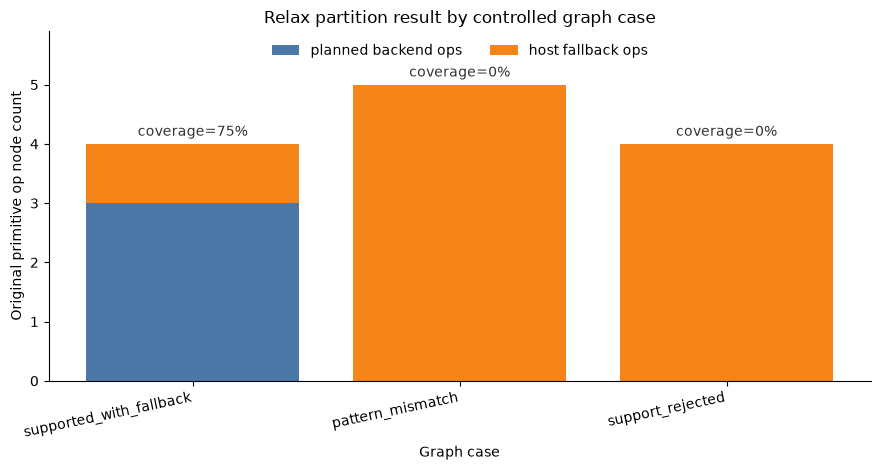

In [9]:
plot_data = partition_table[["planned_offloaded_ops", "fallback_ops"]]
figure, axis = plt.subplots(figsize=(9, 4.8))
axis.bar(
    plot_data.index,
    plot_data["planned_offloaded_ops"],
    color=BLUE,
    label="planned backend ops",
)
axis.bar(
    plot_data.index,
    plot_data["fallback_ops"],
    bottom=plot_data["planned_offloaded_ops"],
    color=ORANGE,
    label="host fallback ops",
)
for index, (case_name, row) in enumerate(partition_table.iterrows()):
    total = row["candidate_primitive_ops"]
    axis.text(
        index,
        total + 0.08,
        f"coverage={row['node_coverage']:.0%}",
        ha="center",
        va="bottom",
        color="#333333",
    )
axis.set_title("Relax partition result by controlled graph case")
axis.set_ylabel("Original primitive op node count")
axis.set_xlabel("Graph case")
axis.set_ylim(0, plot_data.sum(axis=1).max() + 0.9)
axis.legend(frameon=False, ncol=2, loc="upper center")
axis.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
COVERAGE_PLOT_PATH = RUN_DIR / "partition_coverage.png"
figure.savefig(COVERAGE_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

### Coverage 必须先声明分母

本图的 `coverage = planned backend primitive nodes / original primitive nodes`，所以 supported case 是 `3/4`。这是一种 graph coverage，不是：

- FLOPs coverage：MatMul 的 FLOPs 可能远大于 `sin`；
- byte coverage：边界 tensor copy 可能占很多流量；
- latency coverage：一个 fallback 可能因同步/layout conversion 放大端到端成本；
- runtime placement：静态 planned backend 还没有设备执行证据。

求职项目里要同时保留 node/FLOPs/latency 三种口径，不能只挑最好看的那个。

## Checks 1：先验证 partition/grouping 没改数学语义

当前还没有 external codegen，所以不能运行带 `Codegen="project3_toy_npu"` 的 planned module。为了单独验证 graph grouping pass，我们再执行一次 `annotate_codegen=False`：它仍抽出 `Composite` function，但没有把它宣称为外部 backend，因而可以交给同一个 LLVM reference path 编译。

这一步只证明 **semantic grouping parity**，不证明 NPU offload。验证链：

```text
NumPy concrete semantics
        ↕ all elements
original Relax → LLVM
        ↕ all elements
Composite-grouped Relax → LLVM
```

In [10]:
supported_module = original_modules["supported_with_fallback"]
semantic_grouped_module = FuseOpsByPattern(
    backend_patterns,
    bind_constants=False,
    annotate_codegen=False,
)(supported_module)

def compile_and_run(
    module: tvm.IRModule,
    x: np.ndarray,
    weight: np.ndarray,
    bias: np.ndarray,
) -> np.ndarray:
    executable = relax.build(module, LLVM_TARGET)
    virtual_machine = relax.VirtualMachine(executable, tvm.cpu())
    return virtual_machine["main"](
        tvm.runtime.tensor(x, tvm.cpu()),
        tvm.runtime.tensor(weight, tvm.cpu()),
        tvm.runtime.tensor(bias, tvm.cpu()),
    ).numpy()

supported_spec = CASE_SPECS["supported_with_fallback"]
x = np.random.default_rng(RANDOM_SEED).normal(
    size=(supported_spec["M"], supported_spec["K"])
).astype("float32")
weight = np.random.default_rng(RANDOM_SEED + 1).normal(
    size=(supported_spec["K"], supported_spec["N"])
).astype("float32")
bias = np.random.default_rng(RANDOM_SEED + 2).normal(
    size=(supported_spec["N"],)
).astype("float32")

numpy_reference = np.sin(np.maximum(x @ weight + bias, 0))
original_output = compile_and_run(supported_module, x, weight, bias)
grouped_output = compile_and_run(semantic_grouped_module, x, weight, bias)

np.testing.assert_allclose(original_output, numpy_reference, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(grouped_output, original_output, rtol=1e-5, atol=1e-5)

wrong_golden = np.sin(np.maximum(x @ weight - bias, 0))
try:
    np.testing.assert_allclose(grouped_output, wrong_golden, rtol=1e-5, atol=1e-5)
    negative_control_caught = False
except AssertionError:
    negative_control_caught = True
assert negative_control_caught, "The correctness harness failed to reject a wrong golden."

correctness_report = {
    "numpy_vs_original_max_abs_error": float(
        np.max(np.abs(numpy_reference - original_output))
    ),
    "original_vs_grouped_max_abs_error": float(
        np.max(np.abs(original_output - grouped_output))
    ),
    "all_element_parity_passed": True,
    "wrong_golden_negative_control_caught": negative_control_caught,
    "execution_backend": "TVM LLVM CPU for both modules",
}
display(pd.Series(correctness_report, name="value").to_frame())

,value
numpy_vs_original_max_abs_error,0.0
original_vs_grouped_max_abs_error,0.0
all_element_parity_passed,True
wrong_golden_negative_control_caught,True
execution_backend,TVM LLVM CPU for both modules


## Checks 2：故意触发 codegen/runtime Gate，而不是把 partition 当成执行证据

`codegen` 是 code generation 的缩写：在 backend 已选定后，把 composite/低层 IR 变成目标模块、JSON graph、C source 或机器代码。`RunCodegen` 会读取外层 `Codegen` attribute，并通过 FFI 查找 `relax.ext.<backend>`。

我们已经达到的状态是：合法 region 已经被抽出来，`main` 也已经改为调用 backend function。更进一步要真正执行，就必须新增：

1. `relax.ext.project3_toy_npu` codegen entry；
2. 可序列化的 target artifact / runtime module；
3. runtime function lookup、buffer contract、device synchronization；
4. runtime event/placement 与 output parity。

当前 PyPI wheel 没有这些自定义组件。下面的 cell 应捕获缺失，而不是把它隐藏。

In [11]:
custom_codegen_key = f"relax.ext.{BACKEND_NAME}"
custom_codegen_available = tvm.get_global_func(custom_codegen_key, True) is not None
example_npu_codegen_available = (
    tvm.get_global_func("relax.ext.example_npu", True) is not None
)
example_npu_runtime_available = (
    tvm.get_global_func("runtime.ExampleNPUJSONRuntimeCreate", True) is not None
)

codegen_error_summary = ""
if custom_codegen_available:
    codegen_gate_status = "custom codegen registered; ready for the next runtime checks"
else:
    try:
        RunCodegen()(planned_partition_modules["supported_with_fallback"])
        codegen_gate_status = "unexpectedly passed"
    except RuntimeError as error:
        codegen_gate_status = "expected failure caught: missing custom codegen"
        matching_lines = [
            line.strip()
            for line in str(error).splitlines()
            if custom_codegen_key in line or "codegen" in line.lower()
        ]
        codegen_error_summary = " | ".join(matching_lines[:2])

runtime_gate_report = {
    "custom codegen FFI key": custom_codegen_key,
    "custom codegen available": custom_codegen_available,
    "RunCodegen gate": codegen_gate_status,
    "error summary": codegen_error_summary,
    "official example NPU codegen built": example_npu_codegen_available,
    "official example NPU runtime built": example_npu_runtime_available,
    "runtime device execution proven": False,
}
display(pd.Series(runtime_gate_report, name="value").to_frame())
assert custom_codegen_available or codegen_gate_status.startswith("expected failure")
assert not runtime_gate_report["runtime device execution proven"]

,value
custom codegen FFI key,relax.ext.project3_toy_npu
custom codegen available,False
RunCodegen gate,expected failure caught: missing custom codegen
error summary,Check failed: (codegen.has_value()) is false: Codegen is not found: relax.ext.project3_toy_npu
official example NPU codegen built,False
official example NPU runtime built,False
runtime device execution proven,False


### 证据阶梯：本次走到了哪一层

```text
Relax source graph                         ✅
  < structural match + rejection reason   ✅
  < partitioned IR / Composite / Codegen  ✅
  < RunCodegen target module              ❌（Gate 已正确拦截）
  < runtime event / device placement      ❌
  < target-device output parity           ❌
  < target-device latency / profiler      ❌
```

**编译成功不是无 fallback 的证据；partition 成功也不是 runtime 真执行的证据。** 这条区别非常重要，所以在本 notebook 中会多次重复。

## 从 M1 实验映射到公司 Custom NPU：概念同构，API 不同构

| 问题 | M1 / upstream TVM 本实验 | 公司 Custom NPU 扩展 | 证据边界 |
|---|---|---|---|
| model-level graph | upstream Relax，可完整 dump | AGE/ATVM 的 graph compiler / Relay-TIR 路径 | `【官方 schema】docs/N93X-…§4.2.3/§4.2.5` 只支持私有栈基于 ATVM/TIR；**没有证据说它使用 Relax** |
| backend legality | `FusionPattern + PatternCheckContext` | capability / `feasible_region` 中的 dtype、physical layout、shape/alignment 合同 | `【官方 schema】docs/ConvNeXt-…§16.3.4/§16.7.2`；capability 是可行域，不是 kernel 本体 |
| graph partition | `Composite/Codegen` 与 node coverage | compiler partition/fusion log、backend graph | 静态 graph 证明 planned ownership；不能独立证明 runtime placement |
| matrix/vector implementation | 本次尚未进入 target lowering | `Cayley` 是 NPU 内的矩阵/MAC 阵列；`Fermat` 是 NPU 内的 SIMT 向量核 | 最终归属要看 compiler log + runtime core placement，不能靠 kernel 名字猜 |
| runtime evidence | 两边都由 LLVM CPU 执行，只做 semantic parity | mode-12 看 software timer/core placement；mode-15 只做 one-shot Grid 检查 | `【官方 schema】docs/ConvNeXt-…§0/§1.2`；instrumented run 不替代产品 latency |
| correctness / latency | NumPy ↔ original LLVM ↔ grouped LLVM | 先 mode-0 parity 与错误 golden，再做 clean P50/P95；之后另开 profiler run | `docs/Detailed‑Answers…§0/§1/§4/§23` 的统一 Gate |

私有报告顶部声明“部分数据可能存在错误”，所以上表没有把其可信度升级。公开 TVM 实验用于学通用机制，私有材料只用于映射可能的 vendor implementation。

## Custom NPU 最短测试 / 调试 / 优化路径

当前已有：一个可执行的 capability schema、正例与两个负控、partition metrics、host reference parity。迁移到公司软件栈时，按下面顺序增加证据：

1. **SDK/offline compiler，不占板卡**：锁定 compiler/SDK hash；用最小 MatMul graph 查询 op/dtype/layout/shape capability；保存 rejection reason、partition log、before/after graph。需要公司 SDK/container 权限。
2. **Codegen artifact Gate**：检查 AP 是 package manifest、AOM 是单个 kernel target module；确认 shape/dtype/config 与输入一致。静态 artifact 只能证明“生成过”，不证明一次运行真的用了它。
3. **SIM 或 reference runtime**：先做全元素 parity 和错误 golden 负控。若用 instruction simulator，要记录 simulator config；估计 cycle 不能直接冒充 ASIC latency。需要 simulator license/对应 host 环境。
4. **ASIC mode-0**：端到端 smoke → parity → warm-up → P50/P95；每个数字绑定 model/artifact hash、input shape/dtype、硬件分区档位、同步方式和重复次数。需要台架/runtime 权限。
5. **另开 mode-12**：读取真实 Cayley/Fermat core placement、software timer 和 timeline，确认 planned partition 是否变成实际执行。不要把 mode-12 instrumentation latency当产品 latency。
6. **必要时 mode-15 one-shot**：只为静态 Grid/task 证据；有 trace 容量和稳定性风险，不用于 latency distribution。
7. **最后才优化**：先按 compute / memory-layout / boundary-copy / synchronization / fallback 分类，再决定改 pattern、capability、layout、kernel 或 runtime；每次只改一个受控变量并保留反例。

对外面试统一匿名为“某车规 AD SoC / 自研 NPU，矩阵阵列 + SIMT 向量核，支持硬件分区”，不泄露私有路径、寄存器值、内部镜像和账号信息。

## 保存实验记录：让每个结论都能 replay

本次 run 保存：

```text
manifest.json
support_report.json
partition_stats.json
correctness.json
runtime_gate.json
relax_before_<case>.py
relax_partitioned_<case>.py
relax_grouped_llvm_supported.py
partition_coverage.png
report.md
```

这里没有创建 `runtime.csv`：因为尚无 external backend runtime measurement。**缺一份文件比伪造一份 runtime 证据更诚实。**

In [12]:
for case_name in CASE_SPECS:
    (RUN_DIR / f"relax_before_{case_name}.py").write_text(
        original_modules[case_name].script(),
        encoding="utf-8",
    )
    (RUN_DIR / f"relax_partitioned_{case_name}.py").write_text(
        planned_partition_modules[case_name].script(),
        encoding="utf-8",
    )
(RUN_DIR / "relax_grouped_llvm_supported.py").write_text(
    semantic_grouped_module.script(),
    encoding="utf-8",
)

(RUN_DIR / "support_report.json").write_text(
    json.dumps(support_reports, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
(RUN_DIR / "partition_stats.json").write_text(
    json.dumps(partition_records, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
(RUN_DIR / "correctness.json").write_text(
    json.dumps(correctness_report, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
(RUN_DIR / "runtime_gate.json").write_text(
    json.dumps(runtime_gate_report, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

git_commit = command_output(["git", "rev-parse", "HEAD"])
git_dirty = bool(command_output(["git", "status", "--porcelain"]))
manifest = {
    "run_id": RUN_ID,
    "notebook": "notebooks/project3_backend_autotuning/01_relax_pattern_partition_backend_contract.ipynb",
    "git_commit": git_commit,
    "git_dirty": git_dirty,
    "python": platform.python_version(),
    "tvm": tvm.__version__,
    "tvm_git_commit": libinfo.get("GIT_COMMIT_HASH", "unknown"),
    "target": LLVM_TARGET,
    "tvm_build_flags": {
        "USE_LLVM": libinfo.get("USE_LLVM", "unknown"),
        "USE_METAL": libinfo.get("USE_METAL", "unknown"),
    },
    "random_seed": RANDOM_SEED,
    "cpu_threads": CPU_THREADS,
    "backend_name": BACKEND_NAME,
    "pattern_name": PATTERN_NAME,
    "toy_capability": {
        "supported_dtypes": ["float16", "float32"],
        "K_alignment_elements": ALIGNMENT_ELEMENTS,
        "N_alignment_elements": ALIGNMENT_ELEMENTS,
        "local_memory_budget_bytes": LOCAL_MEMORY_BUDGET_BYTES,
    },
    "case_specs": CASE_SPECS,
    "coverage_denominator": "original Relax primitive op node count",
    "runtime_measurement_present": False,
}
(RUN_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

report_text = "\n".join(
    [
        f"# Project 3 · 01 run {RUN_ID}",
        "",
        f"- Target: `{LLVM_TARGET}`; TVM `{tvm.__version__}`",
        f"- Supported case node coverage: {partition_records['supported_with_fallback']['node_coverage']:.0%}",
        f"- Pattern mismatch accepted subgraphs: {partition_records['pattern_mismatch']['accepted_subgraphs']}",
        f"- Support-rejected accepted subgraphs: {partition_records['support_rejected']['accepted_subgraphs']}",
        f"- Semantic grouping parity: {correctness_report['all_element_parity_passed']}",
        f"- Wrong-golden negative control caught: {correctness_report['wrong_golden_negative_control_caught']}",
        f"- External runtime execution proven: {runtime_gate_report['runtime device execution proven']}",
        "",
        "This run validates the Relax pattern/support/partition contract and LLVM semantic parity. It does not claim NPU execution or performance.",
        "",
    ]
)
(RUN_DIR / "report.md").write_text(report_text, encoding="utf-8")

artifact_rows = []
for path in sorted(RUN_DIR.iterdir()):
    if path.is_file():
        artifact_rows.append(
            {
                "artifact": path.name,
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
        )
artifact_index = pd.DataFrame(artifact_rows)
display(artifact_index)
print(f"Run artifacts: {RUN_DIR}")

,artifact,bytes,sha256
0,correctness.json,247,f04f32016466c212b436e971cfaff3bd828f73188a8575617ae58783304625bb
1,manifest.json,1246,139fba0eff35dd413008b144f9d1d8bb4f86aa57f5176b0023216bb56eb8a73e
2,partition_coverage.png,52045,597863fe867d1573dda235f82cc8a539ff1194ec86dadee8693565953aac1a04
3,partition_stats.json,950,cc602487faac7e71b8d0dcd3575556fa659958a01bf01bd220f21614dee72aa7
4,relax_before_pattern_mismatch.py,845,081312d7b367406d189a54b2d4c24c4336d42f720bb16e7d8d6d281d950307c8
5,relax_before_support_rejected.py,738,2f6eb83f137405548f532c70b5e878e7548b2b786ae3d6be86b07d386ea52cf6
6,relax_before_supported_with_fallback.py,738,ed9a0c6123130ada29dd55dd13210198e2d17b6076ac5392e7d912e6e1659522
7,relax_grouped_llvm_supported.py,1278,8e80703ef2b9d38bdd6123984287adcff09ad472988f4d0ee086b2f920e39ed4
8,relax_partitioned_pattern_mismatch.py,845,081312d7b367406d189a54b2d4c24c4336d42f720bb16e7d8d6d281d950307c8
9,relax_partitioned_support_rejected.py,738,2f6eb83f137405548f532c70b5e878e7548b2b786ae3d6be86b07d386ea52cf6


Run artifacts: /Users/yhwang/infer-proj/results/project3_relax_backend/20260903-000943


## Takeaways：由本次 executed outputs 动态生成

In [13]:
supported_metrics = partition_records["supported_with_fallback"]
takeaway_text = "\n".join(
    [
        f"- `supported_with_fallback` 的 structural match={supported_metrics['structural_matches']}、accepted subgraph={supported_metrics['accepted_subgraphs']}；3 个 primitive ops 进入 planned backend，1 个 `sin` fallback，node coverage={supported_metrics['node_coverage']:.0%}。",
        "- `pattern_mismatch` 在 pattern step 被拦截；`support_rejected` 在 capability step 被拦截。两个负控把失败位置分开了。",
        f"- NumPy、original Relax/LLVM、Composite-grouped Relax/LLVM 完成全元素 parity；最大 grouped error={correctness_report['original_vs_grouped_max_abs_error']:.3g}。",
        f"- 错误 bias golden 被 correctness harness 成功拒绝：`{correctness_report['wrong_golden_negative_control_caught']}`。",
        f"- external runtime execution proven=`{runtime_gate_report['runtime device execution proven']}`；因此本次**没有** latency、speedup 或 NPU placement 结论。",
        "",
        "面试版一句话：我先把 backend capability 写成可输出 rejection reason 的合同，再用真实 Relax DPL 做 pattern/support/partition instrumentation，并用结构负控、legality 负控和错误 golden 把 graph ownership 与 correctness 的证据层分开。",
    ]
)
display(Markdown(takeaway_text))

- `supported_with_fallback` 的 structural match=1、accepted subgraph=1；3 个 primitive ops 进入 planned backend，1 个 `sin` fallback，node coverage=75%。
- `pattern_mismatch` 在 pattern step 被拦截；`support_rejected` 在 capability step 被拦截。两个负控把失败位置分开了。
- NumPy、original Relax/LLVM、Composite-grouped Relax/LLVM 完成全元素 parity；最大 grouped error=0。
- 错误 bias golden 被 correctness harness 成功拒绝：`True`。
- external runtime execution proven=`False`；因此本次**没有** latency、speedup 或 NPU placement 结论。

面试版一句话：我先把 backend capability 写成可输出 rejection reason 的合同，再用真实 Relax DPL 做 pattern/support/partition instrumentation，并用结构负控、legality 负控和错误 golden 把 graph ownership 与 correctness 的证据层分开。

## Next Steps：Project 3 的递进实验链

1. `02_relax_to_tir_lowering_codegen_runtime.ipynb`：实现真正的 backend entry / target module，观察 `RunCodegen → call_dps_packed → runtime event`；对 M1 可先用 CPU-backed reference runtime。
2. `03_workload_and_implementation_selection.ipynb`：把 `op/shape/dtype/layout/target/compiler version` 固化为 workload key，并为 MatMul 提供两个真实 implementation。
3. `04_tir_schedule_search_v1.ipynb`：从 naive loop 到 tiled/vectorized/parallel schedule，先 legality pruning，再 grid/random search；每个候选先过 correctness。
4. `05_tuning_database_and_shape_bucket.ipynb`：保存 schedule trace、latency distribution、cache hit/replay，并验证 shape specialization 是否可迁移。
5. `06_profile_guided_custom_npu_optimization.ipynb`：把公司台架的 runtime placement / hot kernel 反馈给 workload search。

⚠️ `MetaSchedule`/cost-model guided tuning 很重要，但不是第一本的必需内容。更不能因为私有 ATVM 目录存在 `meta_schedule` 或文档提到遗传算法，就声称生产 compiler 已使用相同算法；没有 pipeline/API/trace 证据时只能列为待调查线索。

## 附录 A：TVM / IR 技术名词

| 名词 | 英文来源 / 全称 | 它实际上是什么、在代码里干什么 | 本实验观察位置 |
|---|---|---|---|
| TVM | Apache TVM；项目名，不要自行扩写 | 一个 ML compiler stack，维护 frontend/high-level IR/low-level IR/codegen/runtime | `import tvm`、`tvm.support.libinfo()` |
| IR | Intermediate Representation | compiler 内部可遍历、可改写的程序对象，不是日志字符串 | `tvm.IRModule` |
| Relax | 官方名称，不应臆造英文全称 | TVM 中表示 model-level tensor program、shape/type 和 control/data flow 的高层 IR | `make_relax_module()` |
| TIR | Tensor Intermediate Representation | 把一个算子展开成 loop、buffer、index 和 thread mapping 的低层 tensor program IR；本本尚未 lower 到这里 | 下一本 notebook |
| IRModule | Intermediate Representation Module | 全局容器，维护 named functions 和 module attributes，类似一个 compiler translation unit | `module.functions` |
| Function | function | 参数 + return type + body；本实验的 `main` 是 Relax Function | `module['main']` |
| DataflowBlock | data-flow block | 保存一组 SSA bindings，并允许 compiler 根据 def-use 做 graph rewrite | `main.body.blocks` |
| SSA | Static Single Assignment | 每个 IR variable 只定义一次，便于维护 def-use 与做安全改写 | `matmul/bias_add/relu` bindings |
| Binding | binding | `Var = Expr` 这一条 IR 定义记录 | binding inspection table |
| Call | call expression | 记录被调用的 Relax op/global function 和 operands | `relax.Call.op` / `.args` |
| Pass | compiler pass | 读入 IR、返回变换后 IR 的受控程序步骤 | `FuseOpsByPattern(...)` |
| DPL | Dataflow Pattern Language | 用 pattern 对象描述 graph 结构并跨 SSA binding 匹配，不用手写整套 visitor | `make_matmul_pattern()` |

## 附录 B：Backend / BYOC 技术名词

| 名词 | 英文来源 / 全称 | 它实际上是什么、在代码里干什么 | 不能误解成 |
|---|---|---|---|
| pattern matching | pattern = 模式；matching = 匹配 | 在 graph 中识别指定 op 与依赖结构 | target 已支持、设备已执行 |
| support check | support legality check | 对 match 到的 operands 继续检查 dtype/shape/rank/layout/alignment/resource | 单看 op name 的 allowlist |
| FusionPattern | fused graph pattern | pattern + annotations + checker 的 backend registry entry | 已生成 fused kernel |
| partition | graph partitioning | 把不同 IR region 的 ownership 分给 host/backend | `ClusterGroupMode` 物理硬件分区 |
| Composite | composite function attribute | 标记一个 region 对应哪种 fused semantics，供 codegen 识别 | target artifact |
| BYOC | Bring Your Own Codegen | TVM 让外部 backend 接入 pattern/partition/codegen/runtime 的机制 | 自动拥有完整驱动/runtime |
| compiler lowering | lower = 降到更具体层级 | 把 Relax op 逐步改写为 target operator、TIR/buffer loop、intrinsic/目标表示 | 单纯把文本格式换掉 |
| codegen | code generation | 把已选定的 target-specific IR 生成 JSON/C/native object/runtime module | pattern template 本身 |
| FFI | Foreign Function Interface | 用字符串 key 连接 Python compiler pass 与 C++/vendor codegen/runtime function | 远程 RPC |
| runtime module | runtime-loadable module | 维护已编译 functions、constants、imports，让 VM/function lookup 能调用 target code | compile log |
| fallback | fallback execution | target 不合法/不支持的 region 留给 host/其他 backend；会引入边界、同步和潜在 copy | 编译失败；很多 fallback 仍会 compile success |
| coverage | coverage ratio | 本实验是 planned backend node count / original primitive node count | FLOPs/bytes/latency coverage |
| artifact | compiled artifact | 可加载的 model/package/kernel module 及其 manifest | 一次 runtime placement 证据 |
| AP / AOM | AllSpark Package / AllSpark Object Module（内部口径） | AP 是包/清单层，AOM 是单个 kernel 的目标模块 | AP=单 kernel，或 AOM=整个模型 |

## 附录 C：后续 kernel / memory / AutoTuning 名词预习

| 名词 | 英文来源 / 全称 | 它实际上是什么、在代码里干什么 | 工程类比 / 注意点 |
|---|---|---|---|
| implementation | implementation = 具体实现 | 同一 MatMul semantics 的某个 kernel/library algorithm | 类似 LLVM instruction selection 的候选实现 |
| kernel scheduling | schedule = 安排执行次序/映射 | 编译期决定 loop 怎样 split/reorder/tile/vectorize/parallel 以及数据放哪里 | **不等于** runtime task scheduler |
| tile / slice | tile=二维/多维块；slice=区间切片 | 把大 iteration/tensor domain 切成小块，复用 cache/SRAM 或分配线程 | 类似 cache blocking；tile 是策略，slice 也可指 IR/data region |
| vectorize | vector = 向量 | 把相邻 scalar iterations 映射成 SIMD/vector instruction | 要满足连续访问、对齐和 target width |
| unroll | 展开循环 | 复制 loop body，减少 branch/index overhead 并暴露 ILP | 增加 code size/register pressure |
| layout transform | layout = 逻辑轴+物理存储映射 | 改变同一 tensor 元素在 buffer 中的排列，或改变轴解释；可能 materialize copy | 不能因 graph node 消失就断言搬运消失 |
| NPU private layout | vendor-private physical layout | backend 为矩阵阵列/向量单元定义的 blocked/packed/aligned storage contract | 不应从名字猜完整地址公式 |
| stride（AI compiler） | stride = 每跨一个逻辑坐标，物理指针前进多少元素/bytes | view/consumer 用 base+stride 计算地址；可以表达非连续 tensor | 对应 NumPy view / C 指针步长，不是 Conv stride |
| GPU Grid / Block / Warp | CUDA execution hierarchy | Grid 包含 Blocks；Block 包含 threads；Warp 是硬件 lockstep 调度的一组 threads | NX9031 Fermat 可做 SIMT 类比；Cayley 不是 CUDA warp |
| workload key | workload identity key | 用 op/shape/dtype/layout/target/version hash 定位可复用 tuning record | 少一个字段可能错误 replay |
| search space | candidate configuration set | 所有 implementation/schedule 参数组合 | 先 constraint pruning，不能盲目笛卡尔积 |
| cost model | predicted performance model | 用 schedule features 预测候选排序，再让 top-K 上硬件测 | prediction/静态 score 不是 ns/cycle 真值 |
| tuning record | measured schedule record | workload key + schedule trace + measurement config/result | 必须带 correctness 与配置档位 |

## 附录 D：高频面试自检（建议重复口述）

1. **为什么 pattern match 后还要 support check？**
   - pattern 只识别 graph 结构；同一结构的 dtype、shape、layout、alignment、resource 可能不合法。checker 是 implementation legality 的 target contract。

2. **看到 `Codegen="my_npu"` 能说 NPU 已执行吗？**
   - 不能。它只证明 planned partition。还要有 `RunCodegen` 产物、runtime function/event、device/core placement 和 output parity。

3. **fallback 等于 compile failure 吗？**
   - 不等于。compiler 常常让 unsupported region 留在 host，整个模型仍成功编译；性能可能被 boundary copy/layout/sync 放大。

4. **graph partition 和硬件分区有什么区别？**
   - graph partition 决定 node/subgraph ownership；硬件分区决定可用 core/cache/带宽资源。两者会互相影响，但不是一个对象。

5. **TIR schedule 和 runtime scheduler 有什么区别？**
   - TIR schedule 是编译期 loop/data/thread mapping；runtime scheduler 是运行期维护依赖、stream/event 和任务下发。

6. **为什么本实验不比较 latency？**
   - 自定义 external runtime 尚未存在；两条可执行路径都走同一个 LLVM CPU。此时 latency 不能回答 NPU backend 是否更快，先完成 correctness 与 runtime evidence Gate 才有意义。

7. **怎样向公司 NPU 迁移？**
   - 把 toy checker 换成真实 capability schema；保存 partition/rejection；生成并 hash artifact；先 mode-0 parity/负控，再用 runtime placement 证明设备归属，最后在干净配置上测 P50/P95。

## 官方参考与仓库证据

公开机制（优先读官方 primary source）：

- [Apache TVM · Install from PyPI](https://tvm.apache.org/docs/install/pypi.html)
- [Apache TVM · Relax overview](https://tvm.apache.org/docs/deep_dive/relax/index.html)
- [Apache TVM · Dataflow Pattern Language](https://tvm.apache.org/docs/deep_dive/relax/dpl.html)
- [Apache TVM · Bring Your Own Codegen](https://tvm.apache.org/docs/how_to/tutorials/bring_your_own_codegen.html)
- [Apache TVM · External Library Dispatch (BYOC)](https://tvm.apache.org/docs/arch/external_library_dispatch.html)
- [Apache TVM · Build from source](https://tvm.apache.org/docs/install/from_source.html)

仓库内部证据（继承报告的可信度标签，不对外泄露私有信息）：

- `Learning-Guide.md` §14–§26：Project 3 范围与递进路线。
- `【官方 schema】docs/N93X-AllSpark-LLM-Ecosystem-Research-Report.md` §4.2.3/§4.2.5：HAUK TIR/LLVM 与 AGE/ATVM 结构；报告顶部声明部分数据可能错误。
- `【官方 schema】docs/ConvNeXt-DyT-NX9031-Guide&Info .md` §16.3.4/§16.7.2：capability `feasible_region` 是 dtype/layout 可行域，不是 kernel 本体。
- `【官方 schema】docs/ConvNeXt-DyT-NX9031-Guide&Info .md` §0/§1.2：mode-0、mode-12、mode-15 的证据边界。
- `docs/Detailed‑Answers‑for‑Edge‑AI‑Deployment.md` §0/§1/§4/§23：correctness、fallback、runtime placement 的面试标准口径。